# EE200 Project – Question 2
## Name - Pradeep Meena
## Roll No. - 240757



# 1. Frequency De-mixer: 'Unwanted Solo'
## Objective:
To identify and suppress an unwanted instrumental component from a corrupted music signal using frequency analysis and digital filtering.


#  2. Import Required Libraries

In [258]:

import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.signal import welch
from scipy.signal import butter, sosfilt, sosfreqz, sos2tf, tf2zpk
import librosa.display



# 3. Load the input audio signal

In [259]:

input_audio = 'input_audio.wav'
signal_data, sample_rate = librosa.load(input_audio, sr=None)


# 4.Time axis for plotting

In [260]:

time = np.linspace(0, len(signal_data)/sample_rate, num=len(signal_data))


# 5.Plot the original audio signal in time domain

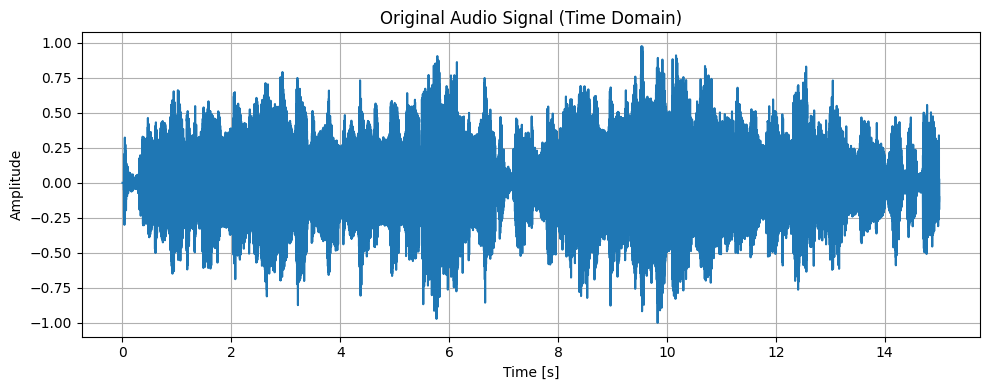

In [261]:

plt.figure(figsize=(10, 4))
plt.plot(time, signal_data)
plt.title("Original Audio Signal (Time Domain)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Power Spectral Density of the original signal


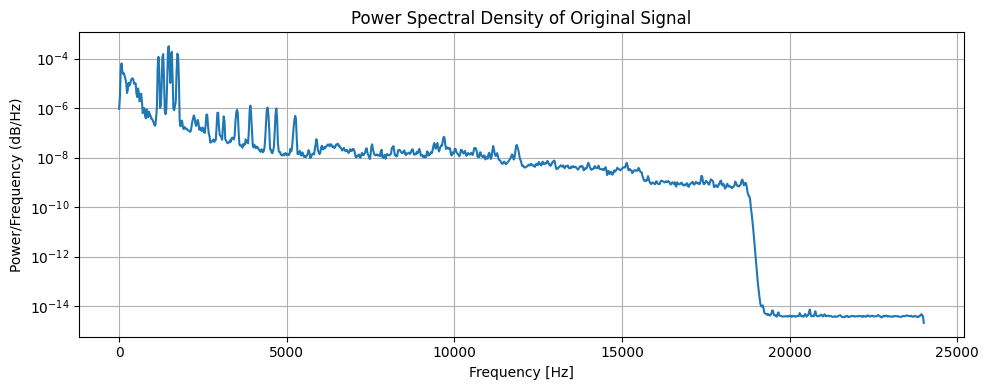

In [262]:

frequencies, psd = welch(signal_data, fs=sample_rate, nperseg=2048)
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)
plt.title("Power Spectral Density of Original Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()

#  7.FFT of the original signal



In [263]:

spectrum = np.fft.fft(signal_data)
freqs = np.fft.fftfreq(len(spectrum), d=1/sample_rate)

# 8.Define stopband frequency range for filtering (in Hz)


In [264]:

stopband_low = 1000
stopband_high = 5000


# 9.Filter the unwanted frequencies by zeroing out the stopband

In [265]:
spectrum_filtered = spectrum.copy()
band_mask = (np.abs(freqs) >= stopband_low) & (np.abs(freqs) <= stopband_high)
spectrum_filtered[band_mask] = 0

# 10. Inverse FFT to get the filtered signal


In [266]:

filtered_signal = np.fft.ifft(spectrum_filtered).real

# 11. Save the filtered audio to a new file


In [267]:

sf.write('output_filtered_audio.wav', filtered_signal, sample_rate)
print(" Filtered audio saved as 'output_filtered_audio.wav'")

 Filtered audio saved as 'output_filtered_audio.wav'


#  12.Design a Butterworth bandstop filter using second-order sections (SOS)


In [268]:

low = stopband_low / (0.5 * sample_rate)
high = stopband_high / (0.5 * sample_rate)
sos = butter(10, [low, high], btype='bandstop', output='sos')

# 13. Plot the Bode plot (magnitude and phase) of the filter


In [269]:

w, h = sosfreqz(sos, worN=2000, fs=sample_rate)
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>


# Magnitude response

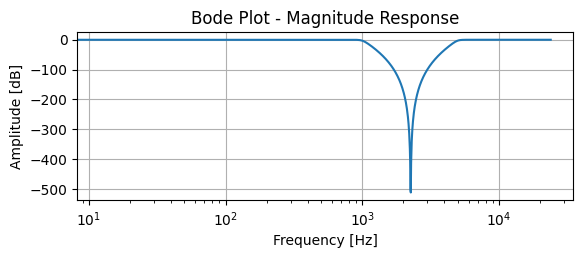

In [270]:
plt.subplot(2, 1, 1)
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.title('Bode Plot - Magnitude Response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.grid(True)


# Phase response

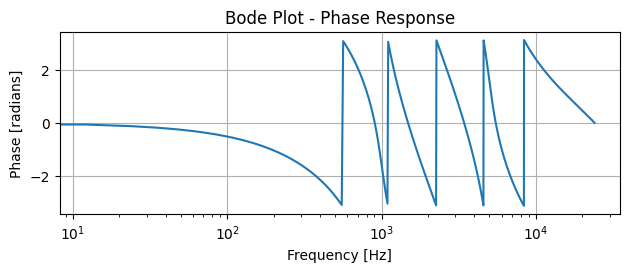

In [271]:

plt.subplot(2, 1, 2)
plt.semilogx(w, np.angle(h))
plt.title('Bode Plot - Phase Response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Phase [radians]')
plt.grid(True)
plt.tight_layout()
plt.show()



# 14.Convert SOS to transfer function and generate pole-zero plot

In [272]:

b, a = sos2tf(sos)
z, p, k = tf2zpk(b, a)


# 15.Pole-zero plot

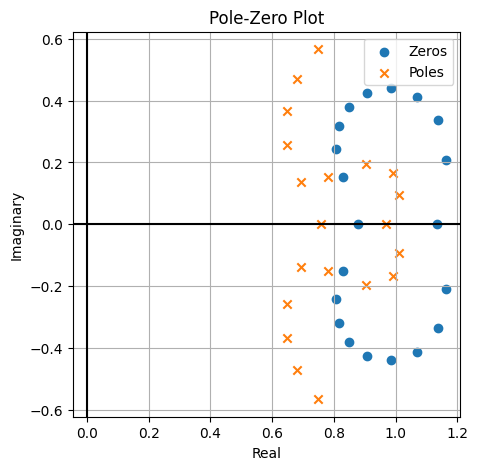

In [273]:

plt.figure(figsize=(5,5))
plt.scatter(np.real(z), np.imag(z), marker='o', label='Zeros')
plt.scatter(np.real(p), np.imag(p), marker='x', label='Poles')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.title('Pole-Zero Plot')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()



# 16.Plot comparison between original and filtered signals in time domain

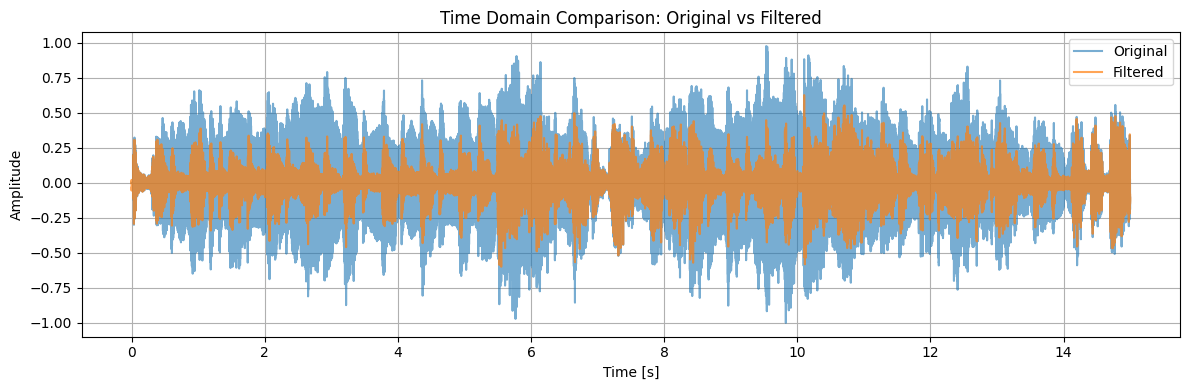

In [274]:

plt.figure(figsize=(12, 4))
plt.plot(time, signal_data, label='Original', alpha=0.6)
plt.plot(time, filtered_signal, label='Filtered', alpha=0.7)
plt.title("Time Domain Comparison: Original vs Filtered")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 17.Power Spectral Density (PSD) comparison between original and filtered signals


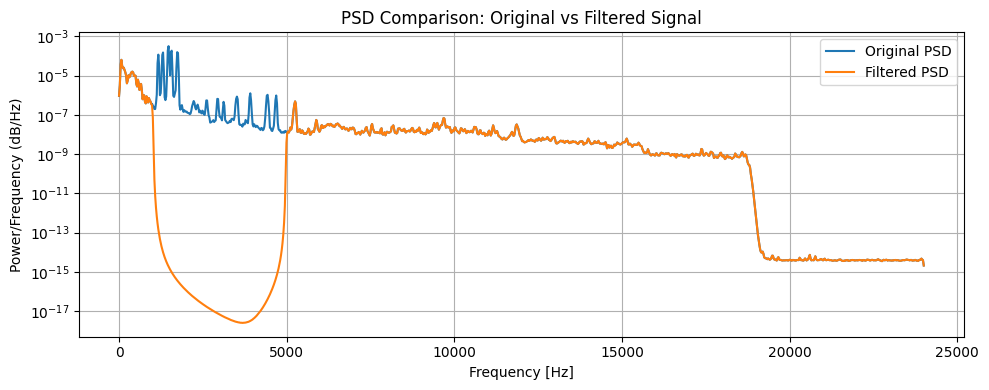

In [275]:

frequencies_orig, psd_orig = welch(signal_data, fs=sample_rate, nperseg=2048)
frequencies_filt, psd_filt = welch(filtered_signal, fs=sample_rate, nperseg=2048)

plt.figure(figsize=(10, 4))
plt.semilogy(frequencies_orig, psd_orig, label='Original PSD')
plt.semilogy(frequencies_filt, psd_filt, label='Filtered PSD')
plt.title("PSD Comparison: Original vs Filtered Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 18. Spectrogram comparison between original and filtered signals


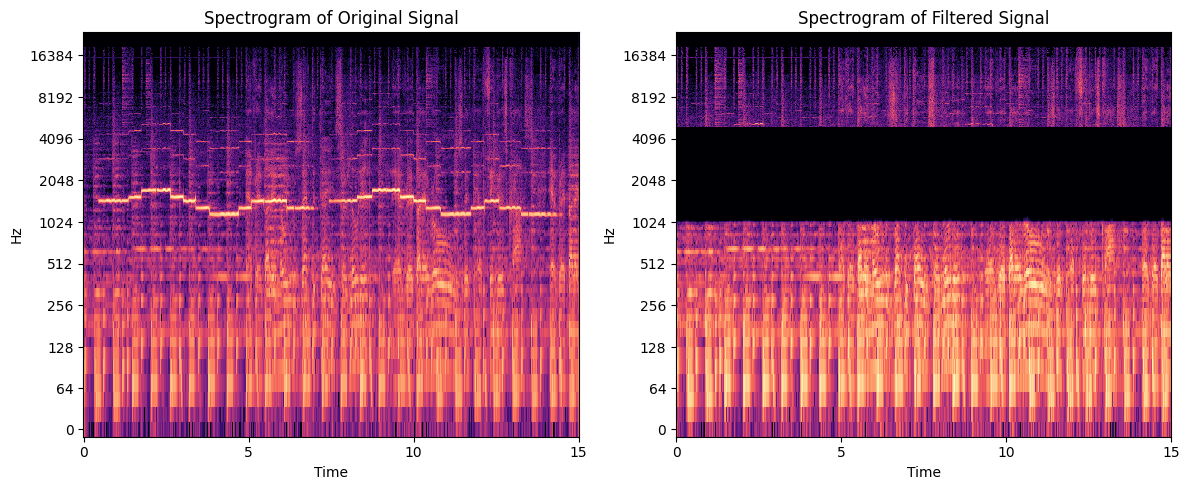

In [276]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(signal_data)), ref=np.max),
                         sr=sample_rate, y_axis='log', x_axis='time')
plt.title('Spectrogram of Original Signal')

plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(filtered_signal)), ref=np.max),
                         sr=sample_rate, y_axis='log', x_axis='time')
plt.title('Spectrogram of Filtered Signal')

plt.tight_layout()
plt.show()